In [12]:
import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import easygems.healpix as egh
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import matplotlib.ticker as ticker
import os
import glob
import xarray as xr
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import SymLogNorm

# from importlib.util import spec_from_file_location, module_from_spec
# from pathlib import Path

# utils_path = Path("../utils.py").resolve()

# spec = spec_from_file_location("utils", utils_path)
# utils = module_from_spec(spec)
# spec.loader.exec_module(utils)

# hp_mods = utils.hp_mods
# plot_all_fields = utils.plot_all_fields

In [13]:
folder = "//work/scratch-pw4/hjwood"
# fname = "GAL_seasonal_mean.nc"
# file = os.path.join(folder, fname)
# ds = xr.open_dataset(file)

In [14]:
# print(ds)

In [15]:
# pr = ds.pr * 3600 # multiply by 3600 to get mm/hr
# print(pr)

In [16]:
# fig, axes = plt.subplots(
#     2, 2,
#     figsize=(10, 8),
#     subplot_kw={"projection": ccrs.Robinson()},
#     constrained_layout=True,
# )

# vmax = float(pr.max())

# for ax, s in zip(axes.flat, pr.season.values):
#     ax.set_global()
#     plot = egh.healpix_show(
#         pr.sel(season=s),
#         ax=ax,
#         cmap="viridis",
#         norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
#     )
#     ax.set_extent([5,50,-35,-5]) 
#     ax.set_title(str(s), fontsize=25)
#     ax.coastlines(color="white")

# cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
# cbar.set_label("Precipitation [mm/hr]", fontsize=20)
# cbar.ax.tick_params(labelsize=20)
# fig.suptitle("GAL", fontsize=30)
# plt.show()

In [17]:
# fname2 = "IMERG_seasonal_mean.nc"
# file2 = os.path.join(folder, fname2)
# ds2 = xr.open_dataset(file2)
# print(ds2)

In [18]:
# pr2 = ds2.precipitation
# print(pr2)

In [19]:
# fig, axes = plt.subplots(
#     2, 2,
#     figsize=(10, 8),
#     subplot_kw={"projection": ccrs.Robinson()},
#     constrained_layout=True,
# )

# vmax = float(pr2.max())

# for ax, s in zip(axes.flat, pr2.season.values):
#     ax.set_global()
#     plot = egh.healpix_show(
#         pr2.sel(season=s),
#         ax=ax,
#         cmap="viridis",
#         norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
#     )
#     gl = ax.gridlines(draw_labels=True)
#     gl.top_labels = False
#     gl.right_labels = False
#     ax.set_extent([5,50,-35,-5]) 
#     ax.set_title(str(s), fontsize=25)
#     ax.coastlines(color="white")

# cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
# cbar.set_label("Precipitation [mm/hr]", fontsize=20)
# cbar.ax.tick_params(labelsize=20)
# fig.suptitle("GAL", fontsize=30)
# plt.show()

In [20]:
# diff = pr - pr2
# print(diff)

In [21]:
# fig, axes = plt.subplots(
#     2, 2,
#     figsize=(10, 8),
#     subplot_kw={"projection": ccrs.Robinson()},
#     constrained_layout=True,
# )

# limit = np.abs(diff).max()

# # norm = TwoSlopeNorm(
# #     vmin=-limit,
# #     vcenter=0,
# #     vmax=limit
# # )

# norm = SymLogNorm(
#     linthresh=0.1,   # linear region around zero
#     linscale=1,
#     vmin=-limit,
#     vmax=limit,
#     base=10
# )

# for ax, s in zip(axes.flat, diff.season.values):
#     ax.set_global()
#     plot = egh.healpix_show(
#         diff.sel(season=s),
#         ax=ax,
#         cmap="coolwarm",
#         norm=norm,
#     )
#     gl = ax.gridlines(draw_labels=True)
#     gl.top_labels = False
#     gl.right_labels = False
#     ax.set_extent([5,50,-35,-5]) 
#     ax.set_title(str(s), fontsize=25)
#     ax.coastlines(color="black")

# cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
# cbar.set_label("Precipitation", fontsize=20)
# cbar.ax.tick_params(labelsize=20)
# fig.suptitle("GAL - IMERG", fontsize=30)
# plt.show()

In [22]:
fname4 = "GAL_seasonal_mean_global.nc"
file4 = os.path.join(folder, fname4)
ds4 = xr.open_dataset(file4)
print(ds4)

<xarray.Dataset> Size: 126MB
Dimensions:  (season: 4, cell: 3145728)
Coordinates:
  * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * cell     (cell) int64 25MB 0 1 2 3 4 ... 3145724 3145725 3145726 3145727
    lat      (cell) float64 25MB ...
    lon      (cell) float64 25MB ...
    crs      int64 8B ...
Data variables:
    pr       (season, cell) float32 50MB ...


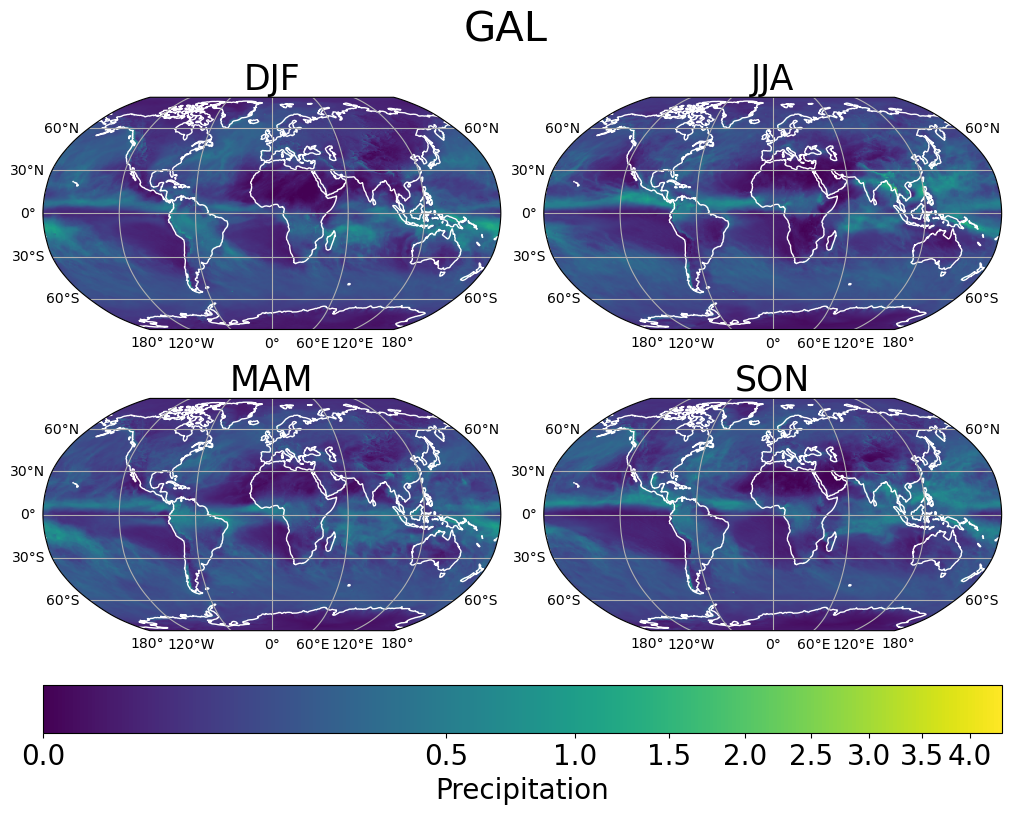

In [30]:
pr3 = ds4.pr *3600

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(pr3.max())

for ax, s in zip(axes.flat, pr3.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        pr3.sel(season=s),
        ax=ax,
        cmap="viridis",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    # ax.set_extent([5,50,-35,-5])
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
fig.suptitle("GAL", fontsize=30)
plt.show()

In [24]:
fname5 = "IMERG_seasonal_mean_global.nc"
file5 = os.path.join(folder, fname5)
ds5 = xr.open_dataset(file5)
print(ds5)

<xarray.Dataset> Size: 126MB
Dimensions:        (season: 4, cell: 3145728)
Coordinates:
  * season         (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * cell           (cell) int64 25MB 0 1 2 3 ... 3145724 3145725 3145726 3145727
    lat            (cell) float64 25MB ...
    lon            (cell) float64 25MB ...
    crs            int64 8B ...
Data variables:
    precipitation  (season, cell) float32 50MB ...


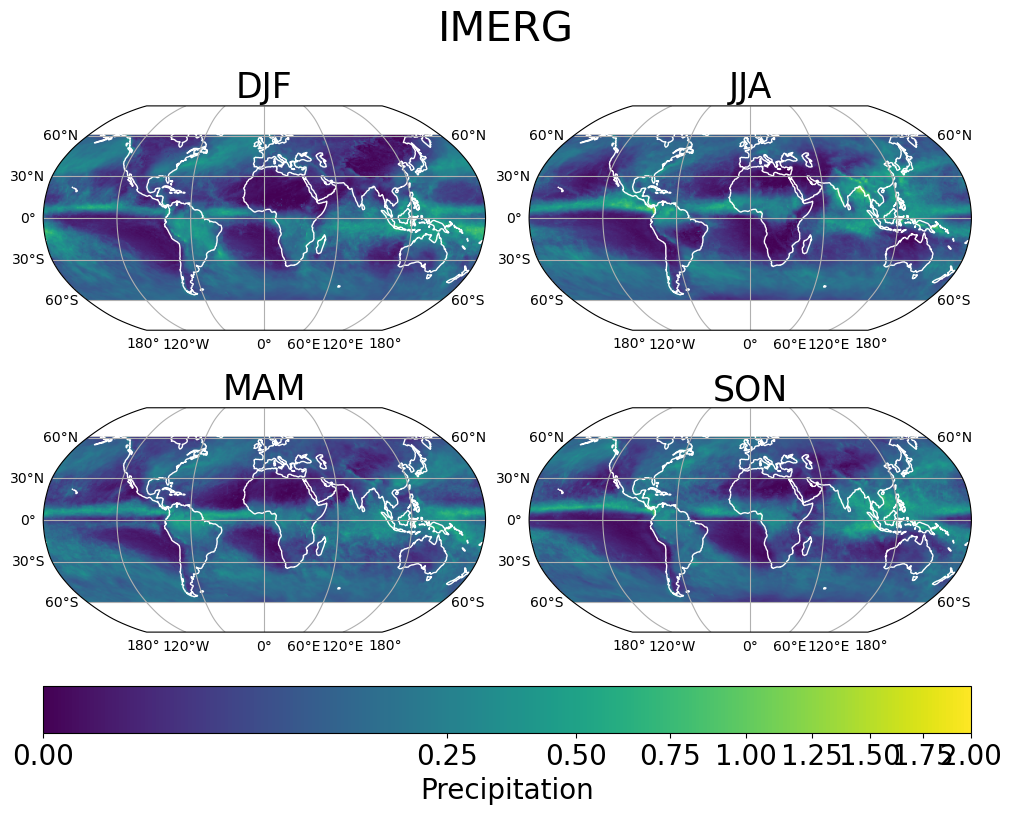

In [31]:
pr4 = ds5.precipitation

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

vmax = float(pr4.max())

for ax, s in zip(axes.flat, pr4.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        pr4.sel(season=s),
        ax=ax,
        cmap="viridis",
        norm=PowerNorm(gamma=0.4, vmin=0, vmax=vmax),
    )
    # ax.set_extent([5,50,-35,-5])
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(str(s), fontsize=25)
    ax.coastlines(color="white")

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation", fontsize=20)
cbar.ax.tick_params(labelsize=20)
fig.suptitle("IMERG", fontsize=30)
# plt.savefig("global_IMERG.png")
plt.show()

In [26]:
diff2 = pr3 - pr4
print(diff2)

<xarray.DataArray (season: 4, cell: 3145728)> Size: 50MB
array([[-3.6371173e-03, -2.4425182e-03, -2.2637038e-03, ...,
         7.0071116e-02,  7.1996644e-02,  6.7541644e-02],
       [ 3.3223048e-02,  4.0168434e-02,  3.0772485e-02, ...,
         7.4787952e-02,  7.7292733e-02,  7.8151748e-02],
       [ 8.2189493e-02,  8.5585162e-02,  8.4335566e-02, ...,
         2.8447253e-01,  3.1263715e-01,  2.7138883e-01],
       [ 2.4762055e-02,  2.0887068e-02,  1.6957236e-02, ...,
         5.3271465e-04, -1.5451945e-04,  1.5286263e-04]],
      shape=(4, 3145728), dtype=float32)
Coordinates:
  * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * cell     (cell) int64 25MB 0 1 2 3 4 ... 3145724 3145725 3145726 3145727
    lat      (cell) float64 25MB 0.0746 0.1492 0.1492 ... -0.1492 -0.0746
    lon      (cell) float64 25MB 45.0 45.09 44.91 45.0 ... 315.1 314.9 315.0
    crs      int64 8B 0
Attributes: (12/15)
    standard_name:     precipitation_flux
    source:            Data from Met Office Unif

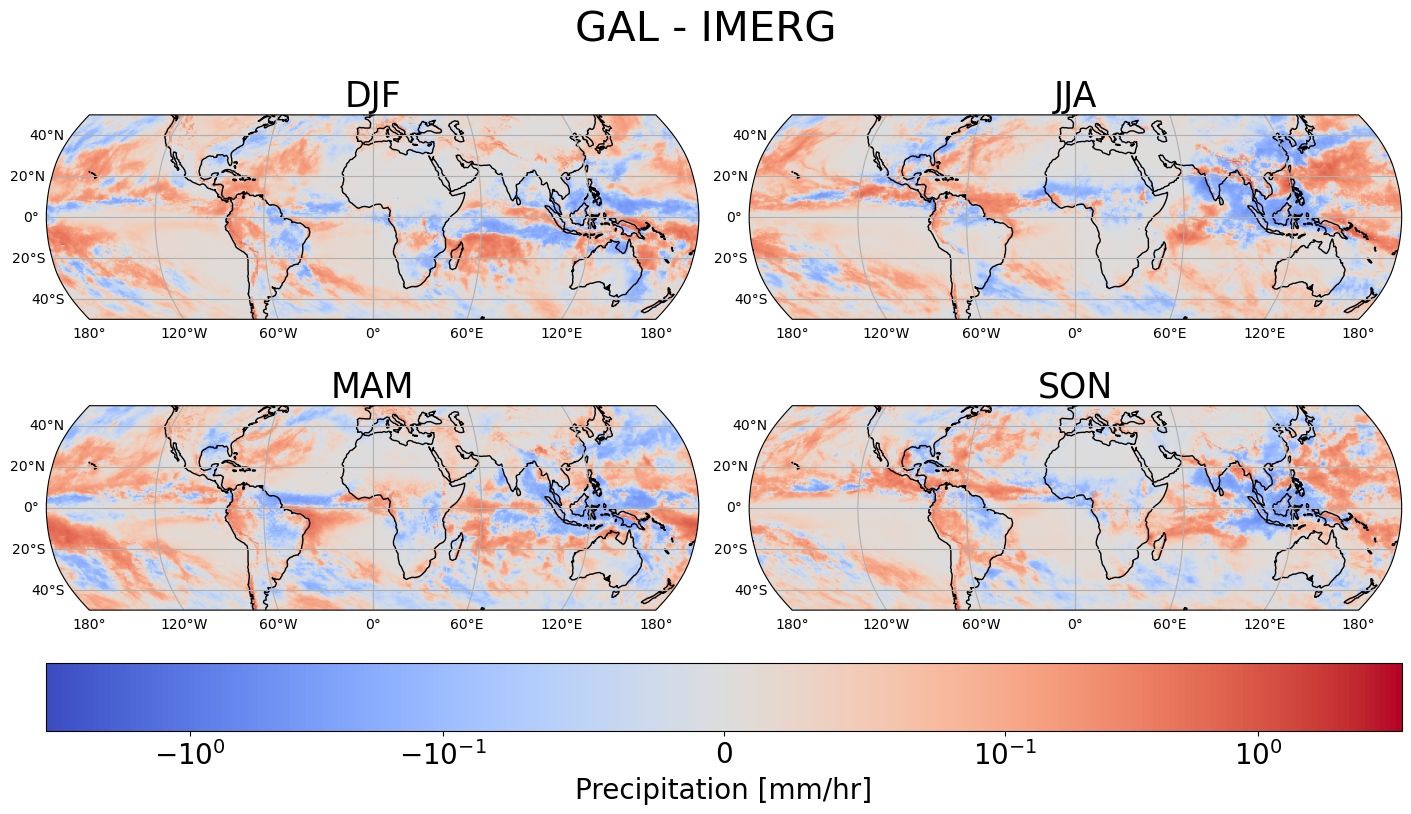

In [32]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

limit = np.abs(diff2).max()

norm = SymLogNorm(
    linthresh=0.1,   # linear region around zero
    linscale=1,
    vmin=-limit,
    vmax=limit,
    base=10
)

# norm = TwoSlopeNorm(
#     vmin=-0.5,
#     vcenter=0,
#     vmax=0.5
# )

for ax, s in zip(axes.flat, diff2.season.values):
    ax.set_global()
    plot = egh.healpix_show(
        diff2.sel(season=s),
        ax=ax,
        cmap="coolwarm",
        norm=norm,)
    ax.set_title(str(s), fontsize=25)
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    ax.coastlines(color="black")
    ax.set_extent([-180,180,-50,50])

cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
cbar.set_label("Precipitation [mm/hr]", fontsize=20)
cbar.ax.tick_params(labelsize=20)
fig.suptitle("GAL - IMERG", fontsize=30)
# plt.savefig("tropical_bias_GAL.png")
plt.show()

In [28]:
regions = [
    {"lat_min": 0, "lat_max": 25, "lon_min": -25, "lon_max": 20, "name": "West Africa"},
    {"lat_min": 0, "lat_max": 35, "lon_min": 50, "lon_max": 110, "name": "South Asia"},
    {"lat_min": 15, "lat_max": 50, "lon_min": 95, "lon_max": 150, "name": "East Asia"},
    {"lat_min": 0, "lat_max": 35, "lon_min": -120, "lon_max": -60, "name": "North America"},
    {"lat_min": -35, "lat_max": -5, "lon_min": 5, "lon_max": 50, "name": "Southern Africa"},
    {"lat_min": -30, "lat_max": 10, "lon_min": 100, "lon_max": 160, "name": "Australia"},
    {"lat_min": -35, "lat_max": 10, "lon_min": -90, "lon_max": -30, "name": "South America"},    
]

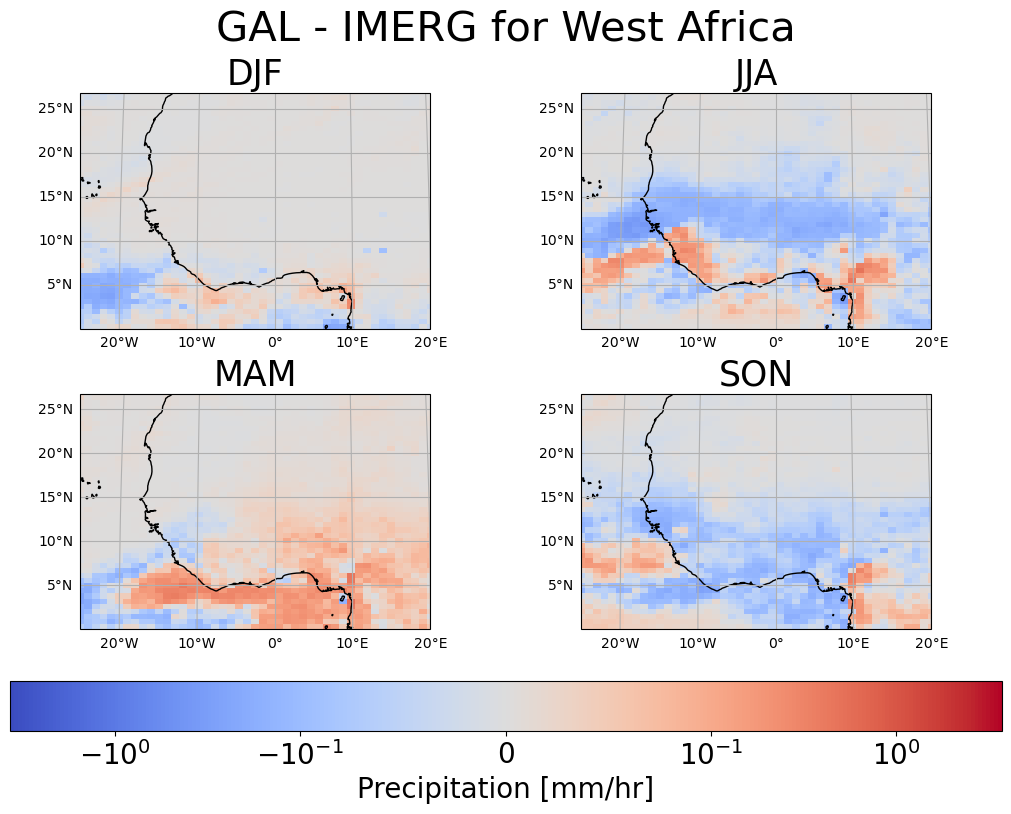

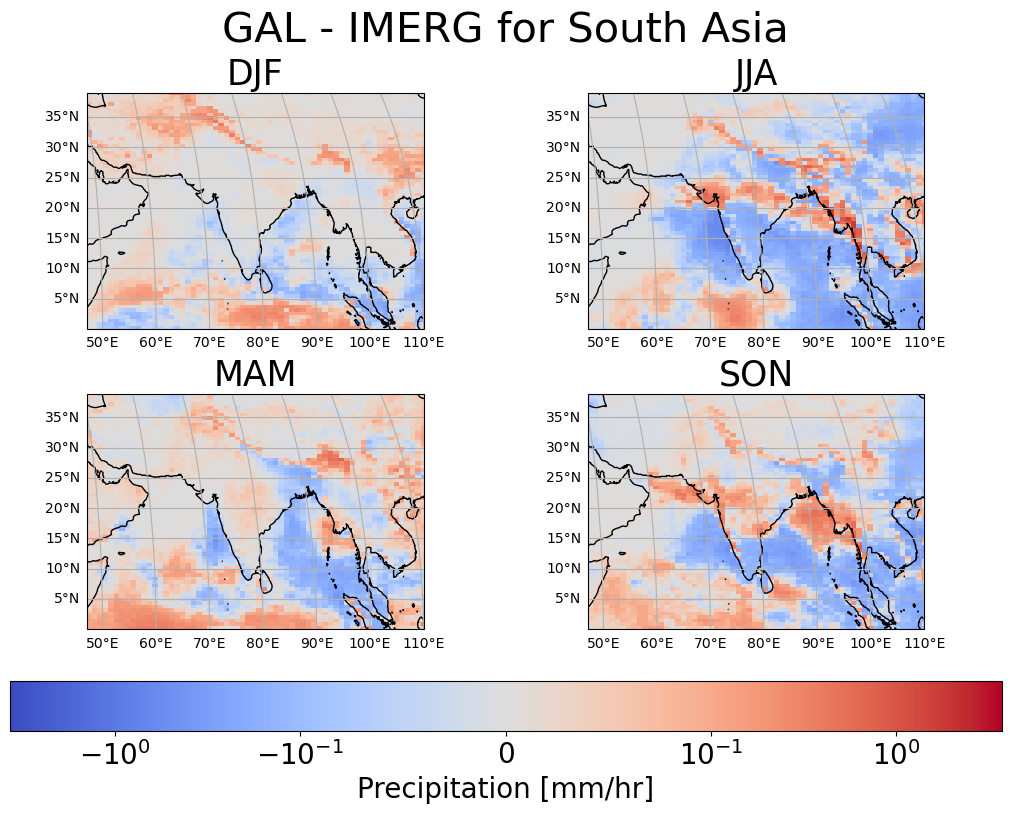

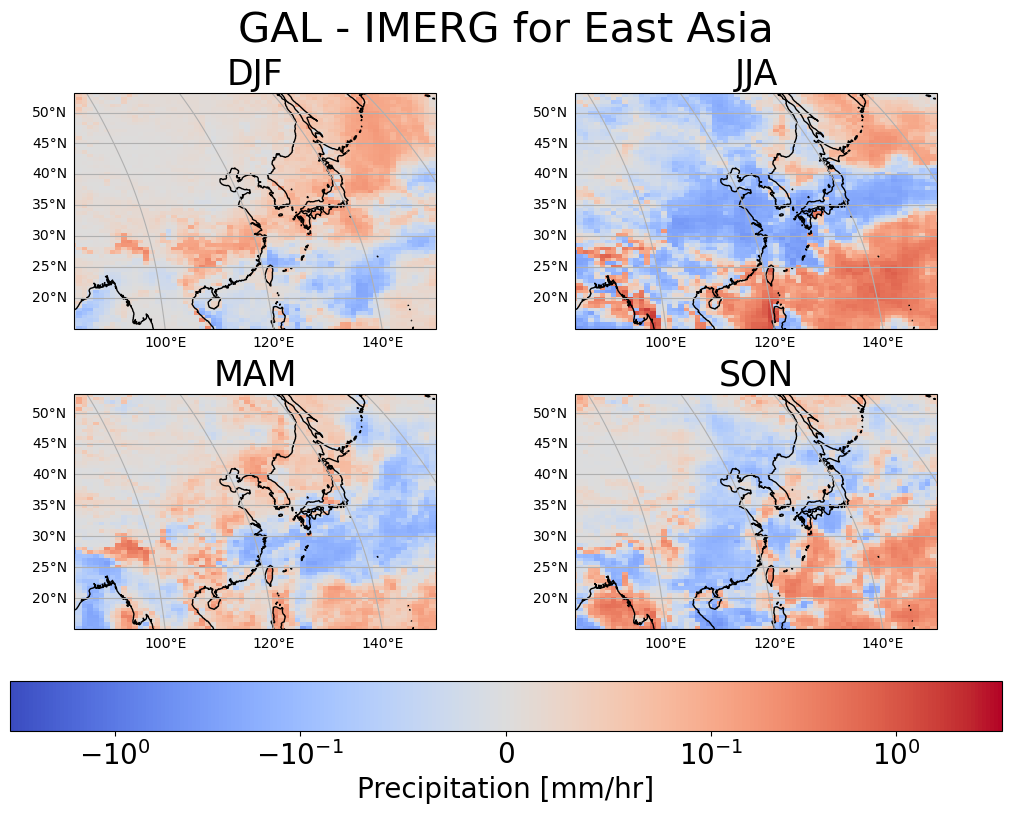

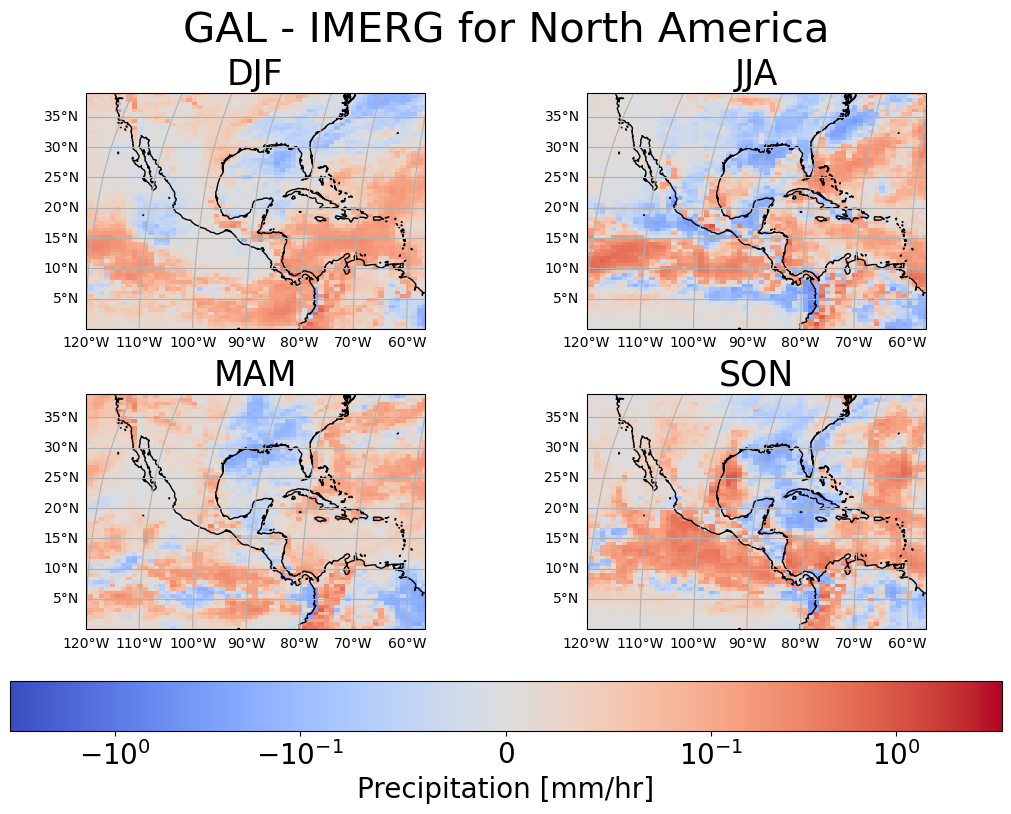

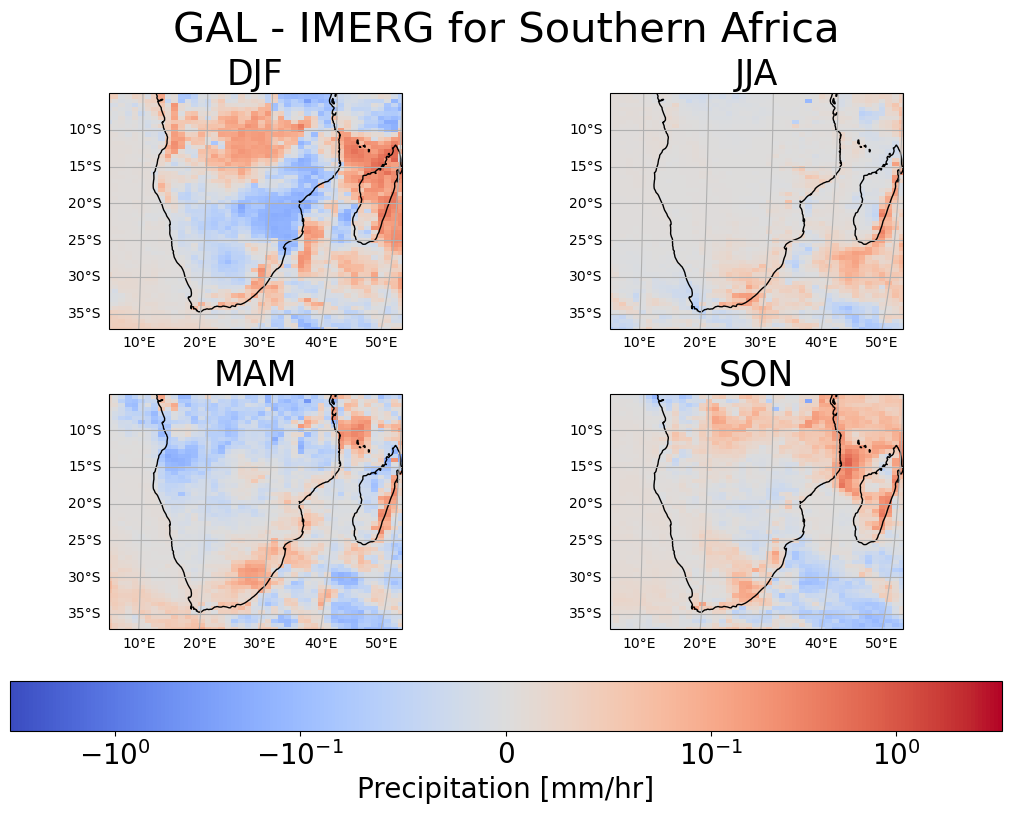

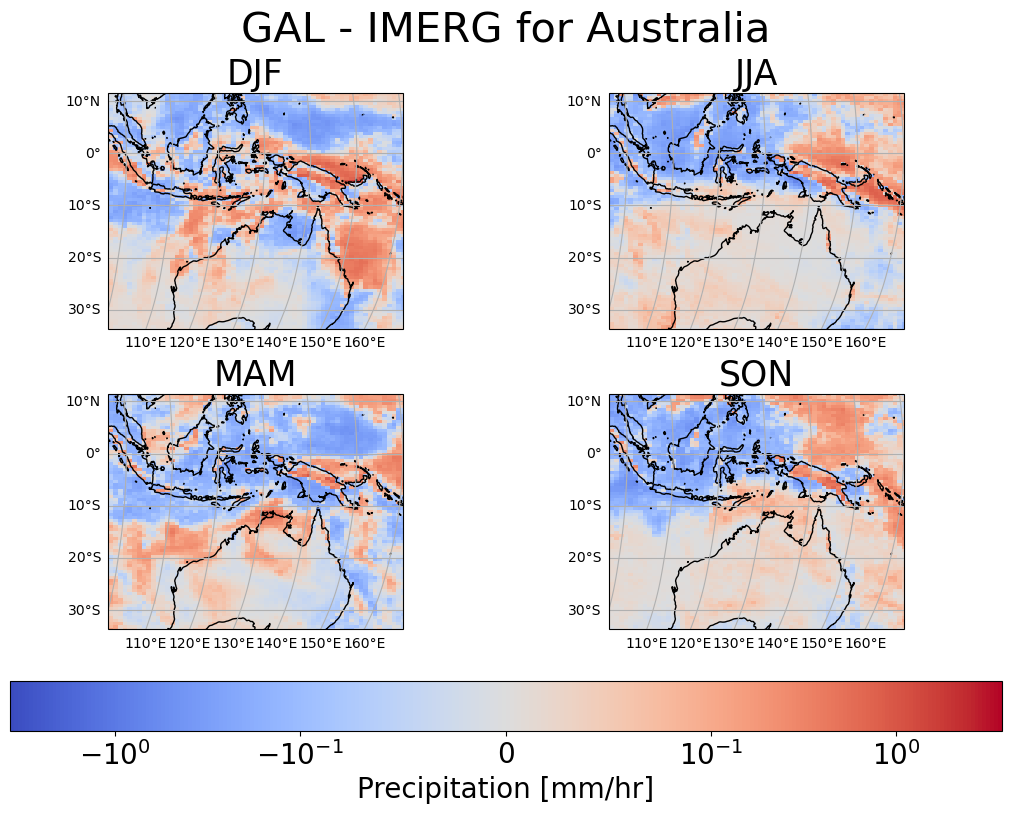

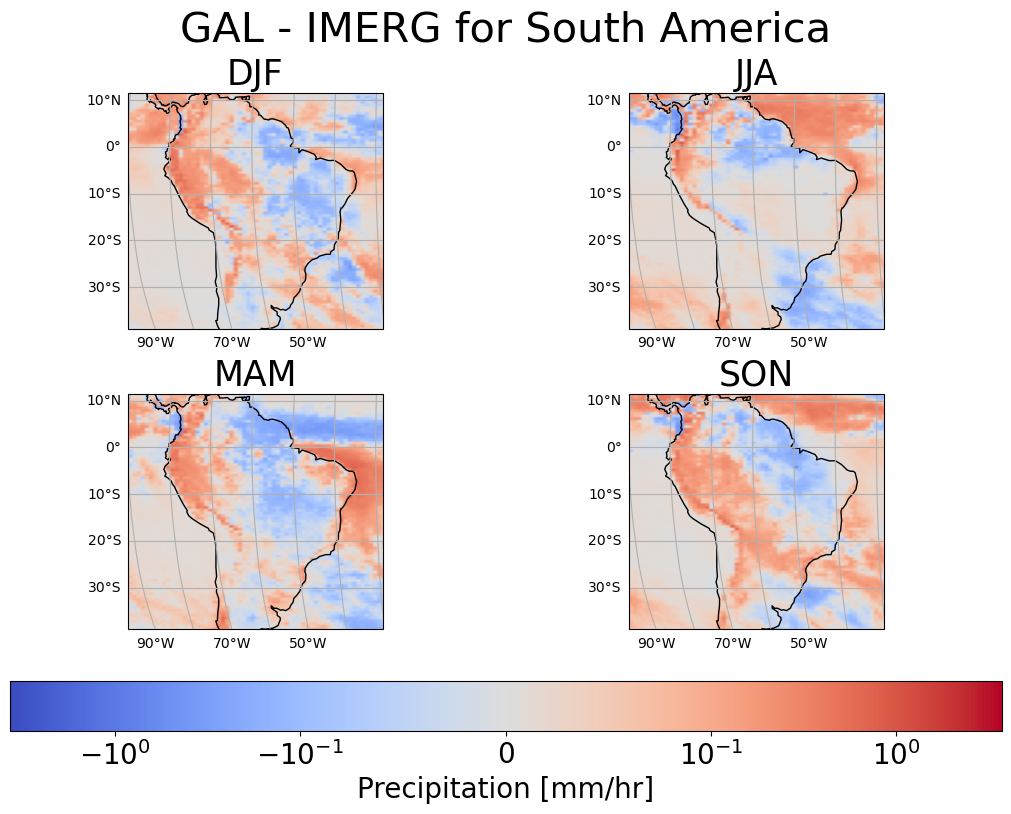

In [33]:
for r in regions:

    fig, axes = plt.subplots(
        2, 2,
        figsize=(10, 8),
        subplot_kw={"projection": ccrs.Robinson()},
        constrained_layout=True,
    )
    
    limit = np.abs(diff2).max()
    
    norm = SymLogNorm(
        linthresh=0.1,   # linear region around zero
        linscale=1,
        vmin=-limit,
        vmax=limit,
        base=10
    )
    
    for ax, s in zip(axes.flat, diff2.season.values):
        ax.set_global()
        plot = egh.healpix_show(
            diff2.sel(season=s),
            ax=ax,
            cmap="coolwarm",
            norm=norm,)
        ax.set_title(str(s), fontsize=25)
        ax.coastlines(color="black")
        ax.set_extent([r["lon_min"],r["lon_max"],r["lat_min"],r["lat_max"]])
        gl = ax.gridlines(draw_labels=True)
        gl.top_labels = False
        gl.right_labels = False
    
    cbar = fig.colorbar(plot, ax=axes, orientation="horizontal")
    cbar.set_label("Precipitation [mm/hr]", fontsize=20)
    cbar.ax.tick_params(labelsize=20)
    name = r["name"]
    fig.suptitle(f"GAL - IMERG for {name}", fontsize=30)
    # plt.savefig(f"{name}_bias_GAL.png")
    plt.show()